In [9]:
from pathlib import Path

path = Path('pi_digits.txt')
contents: str = path.read_text()
lines = contents.splitlines()
pi_string = ''
# for line in lines: 
#     pi_string += line
    
# print(pi_string)
# print(len(pi_string))

for line in lines:
    pi_string += line.lstrip()
    
print(pi_string)
print(len(pi_string))

3.141592653589793238462643383279
32


In [10]:
from pathlib import Path

path = Path('pi_million_digits.txt')
contents = path.read_text()

lines = contents.splitlines()
pi_string = ''
for line in lines:
    pi_string += line.lstrip()
    
print(f"{pi_string[:52]}")
print(len(pi_string))


3.14159265358979323846264338327950288419716939937510
1000002


In [13]:
birthday = input("Enter your birthday, in the form mmddyy: ")
if birthday in pi_string:
    print("Your birthday appears in the first million digits of pi!")
else:
    print("Your birthday does not appear in the first million digits of pi.")

Your birthday appears in the first million digits of pi!


In [14]:
from pathlib import Path

path = Path('Programming.txt')
path.write_text("I love programming")

18

In [17]:
from pathlib import Path

contents = "I love programming.\n"
contents += "I love creating new games\n"
contents += "I also love working with data. \n"

path = Path('Programming.txt')
path.write_text("I love programming")

18

## 10.3 예외
### 10.3.1 ZeroDivisionError 예외처리

In [18]:
try:
    print(5/0)

except ZeroDivisionError:
    print("You can't divdie by zero!")

You can't divdie by zero!


### 10.3.2 try-except문 ~ 10.3.4 else 블록

In [5]:
print("Give me two numbers, and I'll divide them.")
print("Enter 'q' to quit.")

while True:
    first_number = input("\nFirst number: ")
    if first_number == 'q':
        break
    second_number = input("Second number: ")
    if second_number == 'q':
        break
    try:
        answer = int(first_number) / int(second_number)
    except ZeroDivisionError:
        print("Error")
    else:
        print(answer)

Give me two numbers, and I'll divide them.
Enter 'q' to quit.
2.0


### 10.3.5 FileNotFoundError 예외 처리 ~ 10.3.6 텍스트 분석하기

In [ ]:
from pathlib import Path

path = Path('../chapter_10/partial_programs/exceptions/alice.txt')
try:
    contents = path.read_text(encoding='utf-8')
except FileNotFoundError:
    print(f"Sorry, the file {path} does not exist.")

else:
    words = contents.split()
    num_word = len(words)
    print(f"The file [{path}] has about {num_word} words.")

The file [..\chapter_10\partial_programs\exceptions\alice.txt] has about 29594 words.


### 10.3.7 여러 파일 다루기

In [42]:
from pathlib import Path

def count_words(path):
    '''파일에 포함된 단어 개수를 대략적으로 count'''
    try:
        contents = path.read_text(encoding='utf-8')
    except FileNotFoundError:
        print(f"Sorry, the file {path} does not exist.")

    else:
        words = contents.split()
        num_word = len(words)
        # 중복 제거: set 사용!
        unique_words = set(words)
        num_unique = len(unique_words)

        print(f"The file [{path}] has about {num_word} words.")
    
    return unique_words, num_unique
path = Path('../chapter_10/partial_programs/exceptions/alice.txt')
count_words(path)


The file [..\chapter_10\partial_programs\exceptions\alice.txt] has about 29594 words.


({'remark,',
  'Knave,',
  'first;',
  'maps',
  'all,”',
  'Who',
  'just',
  '“That',
  'like.”',
  '“Up,',
  'now—Don’t',
  'eyes:',
  'cried.',
  'William,”',
  'neither',
  'passage:',
  'sigh,',
  'temper!”',
  'fire-irons',
  'bit.”',
  'seen—everything',
  '“Oh,',
  'arches.',
  'part.”',
  'left,',
  'off',
  '“whenever',
  'distributed',
  '“I',
  'must',
  'he',
  'sang',
  'no!',
  'available',
  'shoulders,',
  'afterwards,',
  'breathe’!”',
  'birds,)',
  'writing',
  '“you',
  'deny',
  'Gutenberg',
  'Rome—no,',
  'identify,',
  'tale',
  'myself,”',
  'this',
  'stairs!',
  'case,”',
  'begin,',
  'said,”',
  'Despite',
  'organized',
  'yesterday',
  'louder',
  'interesting.',
  'electronically',
  'invalidity',
  'daisies,',
  'custard,',
  'goes',
  'creatures',
  '‘purpose’?”',
  'Hatter.',
  'presented',
  '“Where’s',
  'slipped',
  'jury,',
  'home,”',
  'accepting',
  'whiting',
  'to—to',
  'started',
  '“poison,”',
  'whispered',
  'opportunity',
  'Dinah:',


In [ ]:
from pathlib import Path

def count_words(filename):
    '''파일에 포함된 단어 개수를 대략적으로 count'''
    try:
        contents = path.read_text(encoding='utf-8')
    except FileNotFoundError:
        print(f"Sorry, the file {path} does not exist.")

    else:
        words = contents.split()
        num_word = len(words)
        print(f"The file [{path}] has about {num_word} words.")

filenames = ['alice.txt', 'siddhartha.txt', 'moby_dick.txt', 'little_women.txt']
for filename in filenames:
    path= Path(filename)
    count_words(path)

The file [alice.txt] has about 29594 words.
Sorry, the file siddhartha.txt does not exist.
The file [moby_dick.txt] has about 215864 words.
The file [little_women.txt] has about 189142 words.


# 16. 데이터 시각화: 데이터 내려받기
## 16.1 csv 파일
### 16.1.1 CVS 파일 헤더 분석하기

In [ ]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt

path = Path('sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader =  csv.reader(lines)
header_row = next(reader)
print(header_row)

['STATION', 'NAME', 'DATE', 'TAVG', 'TMAX', 'TMIN']


### 16.1.2 헤더와 위치 출력하기

In [47]:
for index, column_header in enumerate(header_row):
    print(index, column_header)

0 STATION
1 NAME
2 DATE
3 TAVG
4 TMAX
5 TMIN


### 16.1.3 데이터 추출과 읽기

In [48]:
highs = []
for row in reader:
    high = int(row[4])
    highs.append(high)

print(highs)

[61, 60, 66, 60, 65, 59, 58, 58, 57, 60, 60, 60, 57, 58, 60, 61, 63, 63, 70, 64, 59, 63, 61, 58, 59, 64, 62, 70, 70, 73, 66]


### 16.1. 4 기온 그래프 그리기

2021-07-01 00:00:00


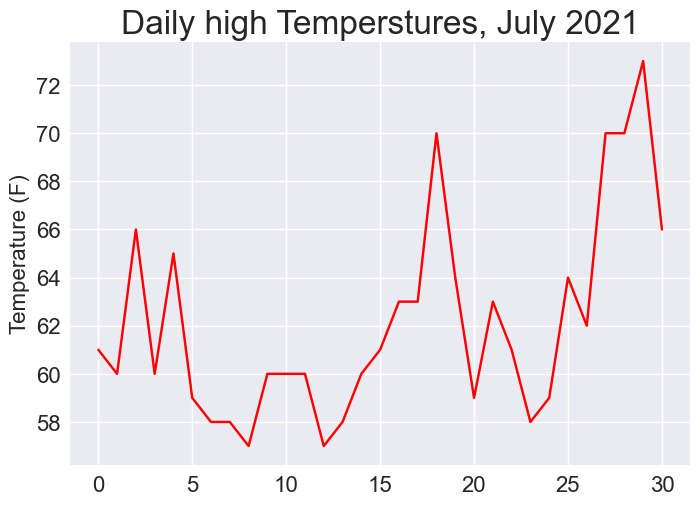

In [ ]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt

path = Path('sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader =  csv.reader(lines)
header_row = next(reader)

plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(highs, color="red")

ax.set_title("Daily high Temperstures, July 2021", fontsize="24")
ax.set_xlabel('', fontsize="16")
ax.set_ylabel("Temperature (F)", fontsize="16")
ax.tick_params(labelsize = 16)

plt.show()

### 16.1.5 datetime 모듈

In [ ]:
from datetime import datetime

first_date = datetime.strptime("2021-07-01", '%Y-%m-%d')
print(first_date)

### 16.1. 6 그래프 날짜에 추가하기

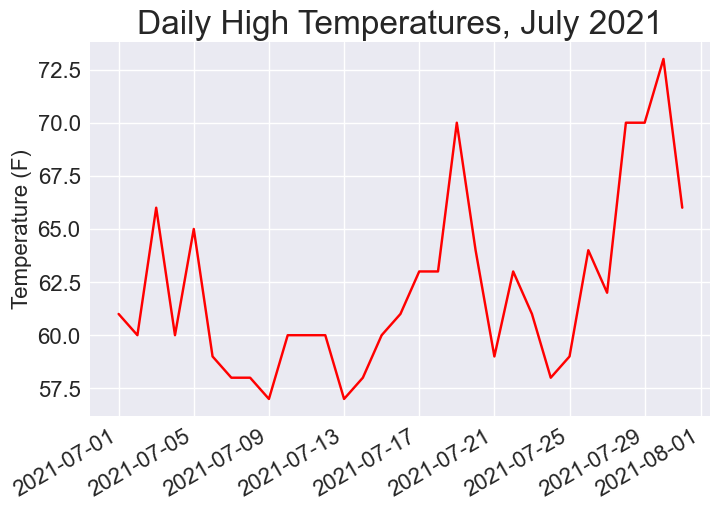

In [66]:
from pathlib import Path
import csv
from datetime import datetime
import matplotlib.pyplot as plt


path = Path('sitka_weather_07-2021_simple.csv')
lines = path.read_text().splitlines()

reader =  csv.reader(lines)
header_row = next(reader)

dates, highs = [], []
for row in reader:
    current_date = datetime.strptime(row[2], '%Y-%m-%d')
    high = int(row[4])
    dates.append(current_date)
    highs.append(high)

# Plot the high temperatures.
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(dates, highs, color='red')

# Format plot.
ax.set_title("Daily High Temperatures, July 2021", fontsize=24)
ax.set_xlabel('', fontsize=16)
fig.autofmt_xdate()
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)

plt.show()

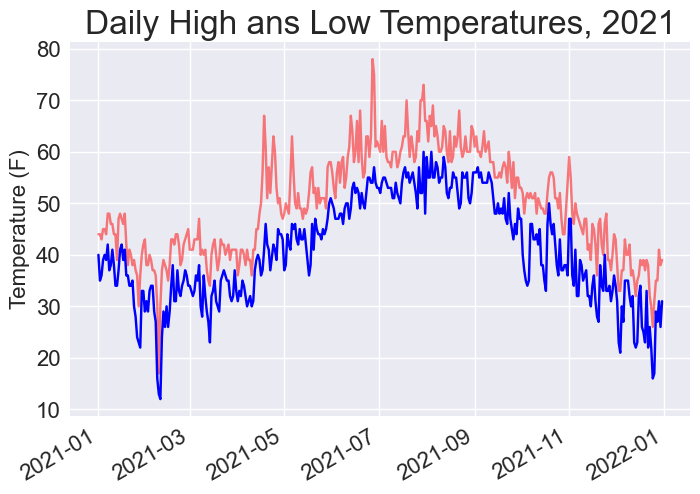

In [ ]:
from pathlib import Path
import csv
from datetime import datetime
import matplotlib.pyplot as plt


path = Path('sitka_weather_2021_simple.csv')
lines = path.read_text().splitlines()

reader =  csv.reader(lines)
header_row = next(reader)

dates, highs, lows = [], [], []
for row in reader:
    current_date = datetime.strptime(row[2], '%Y-%m-%d')
    high = int(row[4])
    low = int(row[5])
    dates.append(current_date)
    highs.append(high)
    lows.append(low)

# Plot the high temperatures.
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(dates, highs, color='red', alpha=0.5)
ax.plot(dates, lows, color='blue', alpha=0.5)

# Format plot.
ax.set_title("Daily High Temperatures, 2021", fontsize=24)
ax.set_title("Daily High ans Low Temperatures, 2021", fontsize=24)
ax.set_xlabel('', fontsize=16)
fig.autofmt_xdate()
ax.set_ylabel("Temperature (F)", fontsize=16)
ax.tick_params(labelsize=16)

plt.show()